# PartUV × Texel Density — 项目 Dashboard（v1.1）

**定位**：本 notebook 是项目的**持续更新 Dashboard**——只加载 `outputs/{p0,p1,p1a,dashboard}`
的已保存结果，不重复实现 `tdlib` 逻辑、默认不重跑 PartUV 或长实验。
原 5 步演示 notebook（V0 baseline）已存档：`archive/partuv_td_test_v0_baseline.ipynb`。

**便携性说明**：本文件已嵌入全部输出（含鞋与车轮两资产的速览），可直接离线阅读。
**修改 `ASSET` 等参数并重跑仅在原项目目录内有效**（依赖 `code/notebook/outputs/` 下的
JSON 与素材图）；分享可运行副本时请连同 `outputs/` 目录一起拷贝，否则重跑时会列出
具体缺失路径（不会静默跳过）。

In [1]:
# ============ 参数 ============
import os
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))  # 从其他目录打开时请手动设置
ASSET = "shoe_22b822"       # "shoe_22b822" | "wheel_92ff6" | "synthetic_halfchecker"
BUDGET = 1_000_000          # 曲线上高亮的预算点 (dashboard 素材图按 1M 生成)
METHODS = ["L1", "L2_heuristic", "RD_hull_global_mse"]
LOAD_SAVED_RESULTS = True   # True: 只读取已保存结果, 不重跑 PartUV / 长实验

%matplotlib inline
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

OUT = os.path.join(PROJECT_ROOT, "code", "notebook", "outputs")
print(f"PROJECT_ROOT (解析后绝对路径) = {PROJECT_ROOT}")
print(f"OUT = {OUT}   exists={os.path.isdir(OUT)}")

ASSETS_ALL = ["shoe_22b822", "wheel_92ff6", "synthetic_halfchecker"]
P1A_KEY = {"L1": "L1", "L2_heuristic": "L2_heuristic",
           "RD_hull_global_mse": "RD_oracle_hull"}   # p1a 输出中的存储键名
LABEL = {"L1": "L1 uniform", "L2_heuristic": "L2 luminance-std",
         "RD_hull_global_mse": "RD_hull_global_mse — teacher candidate v0"}
COLOR = {"L1": "tab:gray", "L2_heuristic": "tab:blue",
         "RD_hull_global_mse": "tab:red"}

MISSING = []
def jload(p):
    if not os.path.exists(p):
        MISSING.append(p)
        print(f"[缺失 JSON] {p}")
        return None
    return json.load(open(p))

def show_row(paths, figw=15.5):
    for p in paths:
        if not os.path.exists(p):
            MISSING.append(p)
            print(f"[缺失素材] {p}")
    ok = [p for p in paths if os.path.exists(p)]
    if not ok:
        return
    fig, axs = plt.subplots(1, len(ok), figsize=(figw, figw / len(ok) * 1.1))
    for ax, p in zip(np.atleast_1d(axs), ok):
        ax.imshow(imread(p)); ax.set_axis_off()
    plt.tight_layout(); plt.show()

p0   = {a: jload(f"{OUT}/p0/{a}/metrics.json") for a in ASSETS_ALL}
p1a  = {a: jload(f"{OUT}/p1a/{a}/metrics.json") for a in ASSETS_ALL if a != "synthetic_halfchecker"}
p1a["synthetic_halfchecker"] = None   # synthetic 仅参与 P0, 无 P1/P1a 数据
dash = {a: jload(f"{OUT}/dashboard/{a}/dashboard_data.json")
        for a in ["shoe_22b822", "wheel_92ff6"]}
dash["synthetic_halfchecker"] = None
rdpt = {a: (jload(f"{OUT}/dashboard/{a}/rd_points.json")
            if dash.get(a) else None) for a in ASSETS_ALL}
snap = jload(f"{OUT}/dashboard/status_snapshot.json")

if not LOAD_SAVED_RESULTS:
    print("重新生成结果: 在 code/ 下用 geomae 环境依次运行 "
          "scripts/run_p0.py, run_p1.py, run_p1a.py, gen_dashboard_assets.py, "
          "scripts/build_dashboard_notebook.py + nbconvert --execute")
print(f"ASSET={ASSET}  BUDGET={BUDGET:,}")
if MISSING:
    print(f"共 {len(MISSING)} 个文件缺失(见上); 缺失项对应的图表会跳过并保留路径提示。")

PROJECT_ROOT (解析后绝对路径) = /root/youjiaZhang/PartUV
OUT = /root/youjiaZhang/PartUV/code/notebook/outputs   exists=True
ASSET=shoe_22b822  BUDGET=1,000,000


## 1. 项目状态

状态表由 `outputs/dashboard/status_snapshot.json` 生成（**冻结快照**，快照日期见输出）；
机器判定 gates 实时读取自 `outputs/p0`、`outputs/p1a` 的 metrics.json。

In [2]:
if snap:
    print(f"状态快照: {snap['version']}  冻结于 {snap['snapshot_date']}  "
          f"(数据源: outputs/dashboard/status_snapshot.json)")
    print("=" * 100)
    for k, v in snap["rows"]:
        print(f"  {k:46s} {v}")
    print("=" * 100)
print()
print("机器判定 gates (实时读取):")
for a in ASSETS_ALL:
    g = (p0.get(a) or {}).get("gates", {})
    m = p1a.get(a) or {}
    print(f"  {a:24s} P0: VALIDITY={g.get('VALIDITY_GATE','—')} "
          f"MECHANISM={g.get('MECHANISM_GATE','—')} "
          f"FINAL={g.get('FINAL_STATUS','—')}")
    if m:
        print(f"  {'':24s} P1a: QUALITY_GATE_main={m['QUALITY_GATE_main']} "
              f"(provisional case-study observation) "
              f"oracle(hull)优于uniform={m['oracle_beats_uniform_main']} "
              f"饱和预算点={m['saturated_budgets']}")

状态快照: v1.2 (P1b)  冻结于 2026-07-14  (数据源: outputs/dashboard/status_snapshot.json)
  P0 mechanism                                   PASS（3/3 资产 e_chart 大幅下降）
  P1/P1a diagnostic run                          完成
  fixed-B_raw (β=0.4, P1/P1a)                    wheel 改善、shoe 退化 — 均为 provisional case-study observation
  fixed-B_signal (P1b β 扫描)                      Simple V1 case-study validated — 共享 β=0.75 双资产 AUC 均改善 >40%
  shoe 在 β=0.4 的退化解读                             与内容权重强度失配相符（P1b: β=0.25/0.5 劣化、β=0.75 改善 ⇒ 强度问题为主）
  RD_hull_global_mse                             teacher candidate v0 — 不参与 Simple V1 定义, 仅诊断参考
  gradient / multiscale / predictor / chart split 未启动（Simple V1 冻结后不自动进入）
  下一步                                            Simple V1 已按预定停止条件冻结（仅当前案例有效），等待确认

机器判定 gates (实时读取):
  shoe_22b822              P0: VALIDITY=PASS MECHANISM=PASS FINAL=TARGET_MATCH_IMPROVED
                           P1a: QUALITY_GATE_main=FAIL (provisional case-study observation) oracle(hull)优于uniform=Tr

## 2. 两资产结果速览（无需修改 `ASSET` 即可见）

| 资产 | 角色 | fixed-B_raw 观察（provisional case-study） |
|---|---|---|
| `shoe_22b822` | 信号难例 | L2 heuristic 全局**退化**；与内容权重强度过大或目标函数失配相符，信号排序是否错误尚未区分 |
| `wheel_92ff6` | 收益例 | L2 heuristic 全局**改善**（主 AUC 减半） |
| `synthetic_halfchecker` | 机制检验 | 仅参与 P0（e_chart→0 机制验证），无 P1/P1a 数据 |

—— shoe_22b822 ——  (主 AUC = 非饱和预算点, log2 域; 越低越好)
   L1 uniform                                   主AUC=0.000737   高频区AUC=0.007004
   L2 luminance-std                             主AUC=0.001348   高频区AUC=0.003127
   RD_hull_global_mse — teacher candidate v0    主AUC=0.000415   高频区AUC=0.003609


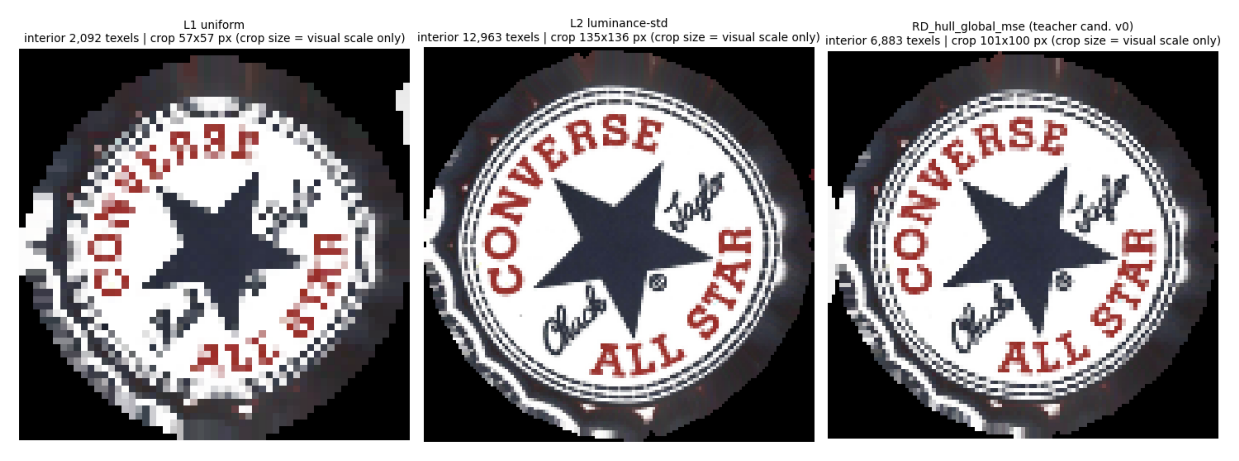

—— wheel_92ff6 ——  (主 AUC = 非饱和预算点, log2 域; 越低越好)
   L1 uniform                                   主AUC=0.001742   高频区AUC=0.014596
   L2 luminance-std                             主AUC=0.000731   高频区AUC=0.006712
   RD_hull_global_mse — teacher candidate v0    主AUC=0.000470   高频区AUC=0.003790


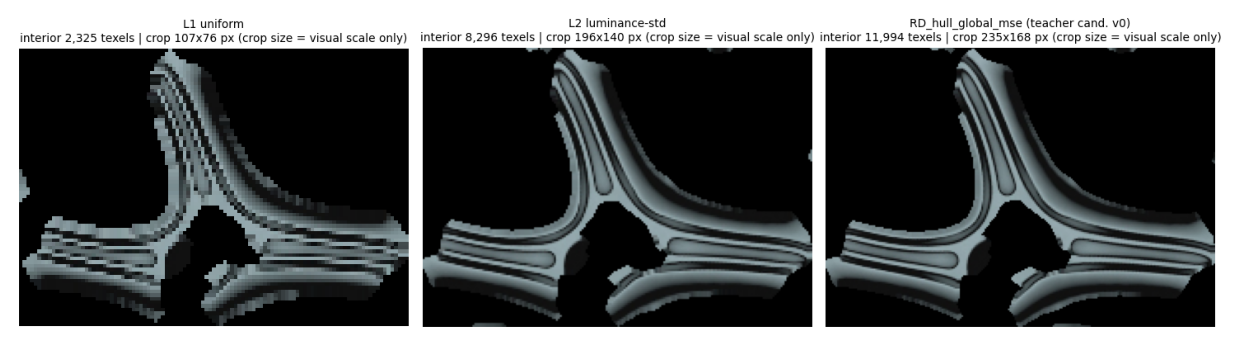

In [3]:
for a in ["shoe_22b822", "wheel_92ff6"]:
    m = p1a.get(a)
    if not m:
        continue
    print(f"—— {a} ——  (主 AUC = 非饱和预算点, log2 域; 越低越好)")
    for meth in METHODS:
        mm = m["methods"][P1A_KEY[meth]]
        print(f"   {LABEL[meth]:44s} 主AUC={mm['auc_main']:.6f}   "
              f"高频区AUC={mm['auc_main_hifreq']:.6f}")
    show_row([f"{OUT}/dashboard/{a}/zoom_compare.png"], figw=12.5)

## 3. 主视觉：最高内容 chart 局部放大（鞋 = Converse logo）

同一 chart 在三种方法的同一 1000² atlas 中的裁剪，标题标注了该 chart 的
**光栅化 interior texel 数**（这是有效纹素的准确度量）。
**注意：裁剪框宽高只是直观尺度，不能直接等同于有效 texel 数**（裁剪框含空白角落，
且不同方法打包位置不同）。右侧小图标记该 chart 在 3D 模型上的位置。

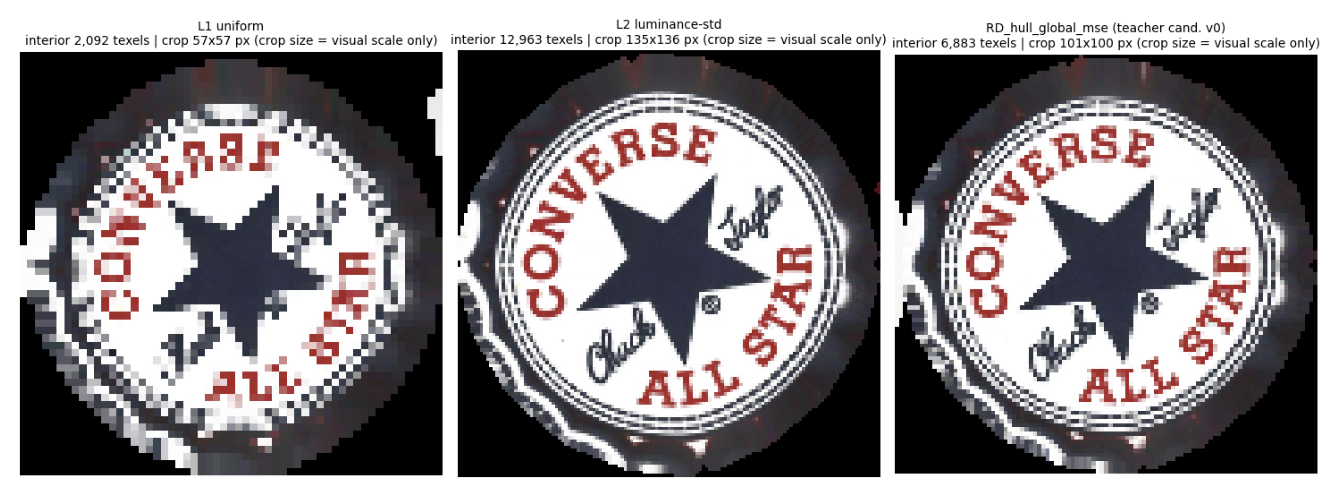

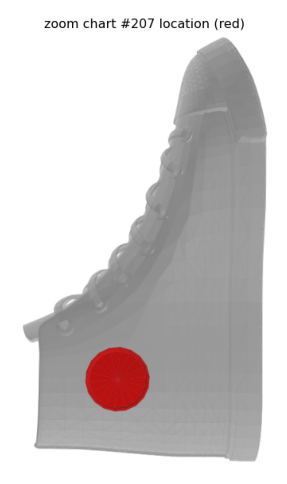

zoom chart = #207 (面积加权 luminance-std 最高的 >=100 面 chart)
   L1 uniform                                   rasterized interior =   2,092 texels
   L2 luminance-std                             rasterized interior =  12,963 texels
   RD_hull_global_mse — teacher candidate v0    rasterized interior =   6,883 texels


In [4]:
show_row([f"{OUT}/dashboard/{ASSET}/zoom_compare.png"], figw=13.5)
show_row([f"{OUT}/dashboard/{ASSET}/zoom_location.png"], figw=4.5)
d = dash.get(ASSET)
if d:
    print(f"zoom chart = #{d['zoom_chart']} (面积加权 luminance-std 最高的 >=100 面 chart)")
    for meth in METHODS:
        dm = d["methods"][meth]
        print(f"   {LABEL[meth]:44s} rasterized interior = {dm['zoom_interior_texels']:>7,} texels")

## 4. UV layout 对比（共享 colorbar，zoom chart 已圈注）

三方法使用相同 PartUV charts、相同 shelf packer，仅 per-chart 缩放不同。
着色 = 该 chart **打包后实际 UV 面积相对 L1 的 log2 倍率**（共享色标：红=获得更多纹素，
蓝=被压缩）；绿圈 = zoom chart（鞋 logo）。

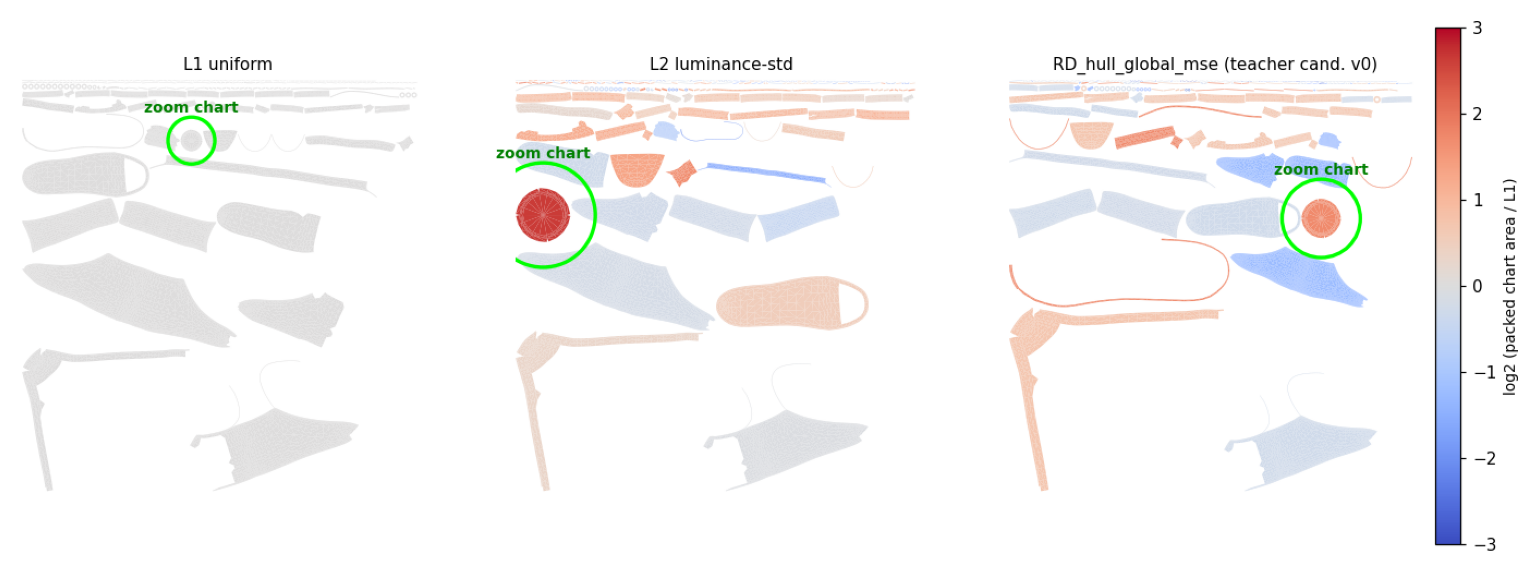

L1 uniform                                   B_signal=0.25M   chart面积倍率 q^2 (min/med/max) = 1.00 / 1.00 / 1.00
L2 luminance-std                             B_signal=0.27M   chart面积倍率 q^2 (min/med/max) = 0.27 / 0.85 / 6.20
RD_hull_global_mse — teacher candidate v0    B_signal=0.21M   chart面积倍率 q^2 (min/med/max) = 0.14 / 0.82 / 3.29


In [5]:
show_row([f"{OUT}/dashboard/{ASSET}/layout_compare.png"], figw=15.5)
d = dash.get(ASSET)
if d:
    for meth in METHODS:
        dm = d["methods"][meth]
        print(f"{LABEL[meth]:44s} B_signal={dm['B_signal']/1e6:.2f}M   "
              f"chart面积倍率 q^2 (min/med/max) = "
              f"{dm['q2_min']:.2f} / {dm['q2_med']:.2f} / {dm['q2_max']:.2f}")

## 5. 同视角渲染对比（含 reference）与绝对误差热图

上排：reference（原贴图）+ 三方法 1000² rebake 的同视角紧裁渲染。
1M 预算下整体观感差异小是预期的——分配差异集中在高频局部（见 §3）与
给定预算下的重建误差（§6/§7）。
下排：逐面 **absolute-error heatmap**（|重建−reference| 的逐面均值，共享色标，亮=误差大）。

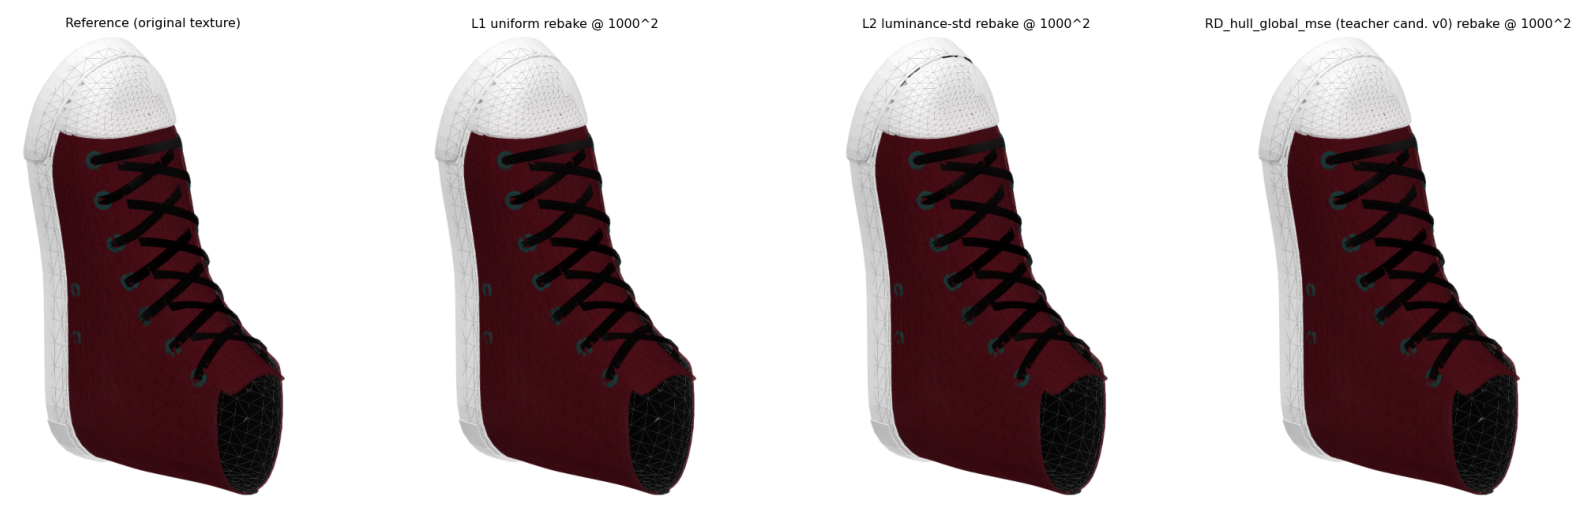

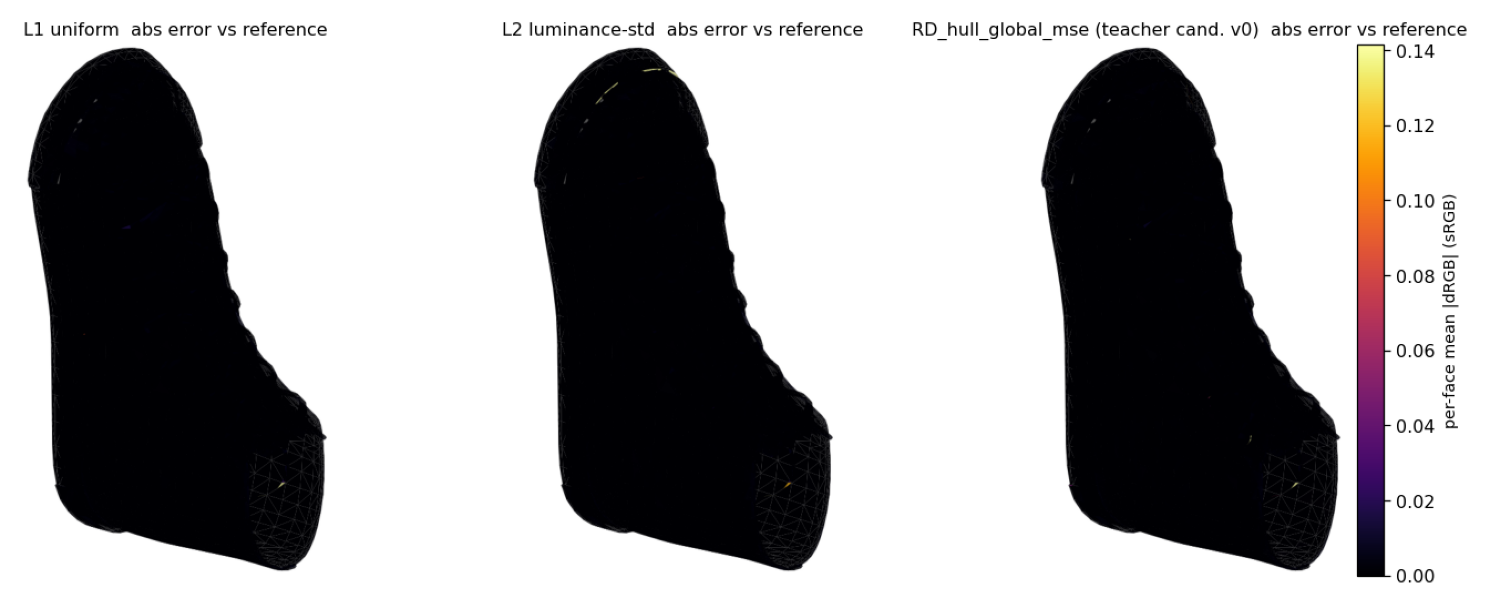

In [6]:
show_row([f"{OUT}/dashboard/{ASSET}/renders_compare.png"], figw=16)
show_row([f"{OUT}/dashboard/{ASSET}/error_heatmap.png"], figw=15)

## 6. Global error–budget 曲线 — 两种协议分开显示

- **左图（当前结论依据）**：**fixed-B_raw** 协议——全方法同 atlas 分辨率 R。
  空心点 = reference 已饱和的预算点（不计入主 AUC）。
- **右图（仅展示）**：同一批数据按**实测 B_signal** 换轴。固定 R ≠ 固定有效纹素预算；
  受控的 fixed-B_signal 协议 **NOT YET EVALUATED**，右图不能作为其替代。

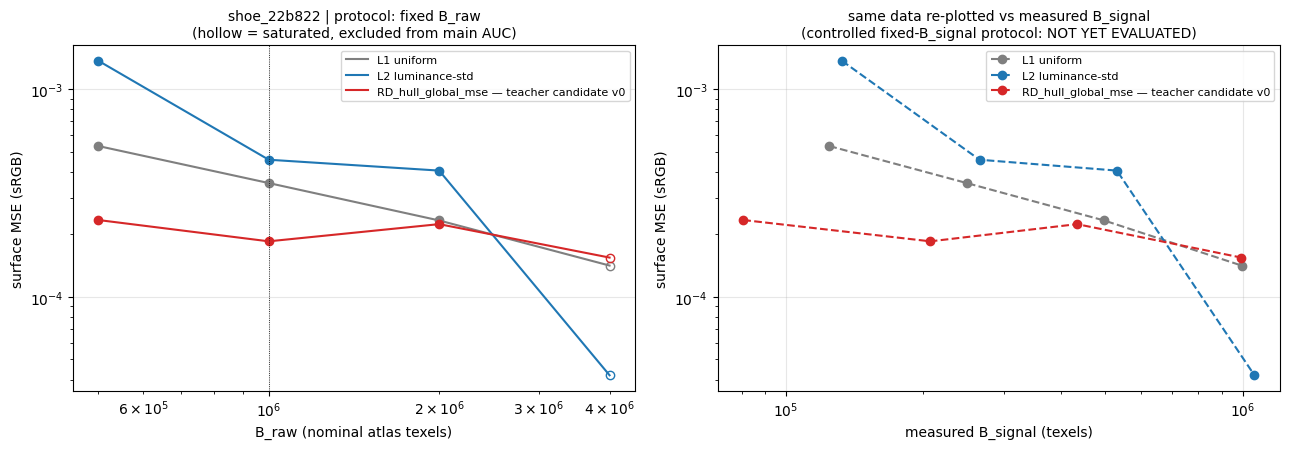

主 AUC (非饱和区间, log2 域; provisional case-study observation):
  L1 uniform                                   0.000737
  L2 luminance-std                             0.001348
  RD_hull_global_mse — teacher candidate v0    0.000415


In [7]:
def budget_curves(metric_key, ylab):
    m = p1a.get(ASSET)
    if not m:
        print(f"该资产无 P1a 数据: {OUT}/p1a/{ASSET}/metrics.json (synthetic 仅参与 P0)")
        return
    Bs = m["budgets"]; sat = set(m["saturated_budgets"])
    fig, axs = plt.subplots(1, 2, figsize=(13, 4.6))
    for meth in METHODS:
        k = P1A_KEY[meth]
        errs = [m["per_budget"][str(B)][k][metric_key] for B in Bs]
        sigs = [m["per_budget"][str(B)][k]["B_signal"] for B in Bs]
        axs[0].plot(Bs, errs, "-", color=COLOR[meth], label=LABEL[meth])
        for B, e in zip(Bs, errs):
            axs[0].plot(B, e, "o", mfc="none" if B in sat else COLOR[meth],
                        mec=COLOR[meth])
        axs[1].plot(sigs, errs, "o--", color=COLOR[meth], label=LABEL[meth])
    axs[0].axvline(BUDGET, color="k", lw=0.6, ls=":")
    axs[0].set_xlabel("B_raw (nominal atlas texels)")
    axs[0].set_title(f"{ASSET} | protocol: fixed B_raw\n(hollow = saturated, excluded from main AUC)",
                     fontsize=10)
    axs[1].set_xlabel("measured B_signal (texels)")
    axs[1].set_title("same data re-plotted vs measured B_signal\n(controlled fixed-B_signal protocol: NOT YET EVALUATED)",
                     fontsize=10)
    for ax in axs:
        ax.set_xscale("log"); ax.set_yscale("log"); ax.set_ylabel(ylab)
        ax.grid(alpha=0.3); ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()
    kk = "auc_main" if metric_key == "err" else "auc_main_hifreq"
    print("主 AUC (非饱和区间, log2 域; provisional case-study observation):")
    for meth in METHODS:
        print(f"  {LABEL[meth]:44s} {m['methods'][P1A_KEY[meth]][kk]:.6f}")

budget_curves("err", "surface MSE (sRGB)")

## 7. 高频区 error–budget 曲线

子集 = **reference 纹理自身**亮度梯度 top-10% 的评价采样点（与分配信号无关，防止
大面积平坦区掩盖小细节损失）。协议同 §6（左受控 / 右换轴展示）。

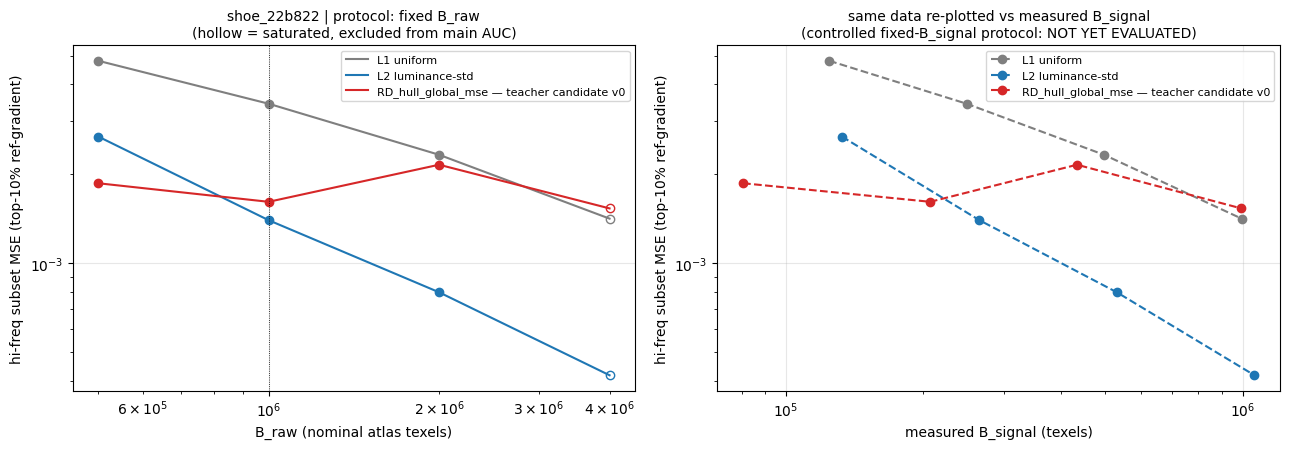

主 AUC (非饱和区间, log2 域; provisional case-study observation):
  L1 uniform                                   0.007004
  L2 luminance-std                             0.003127
  RD_hull_global_mse — teacher candidate v0    0.003609

注: 鞋上 L2 heuristic 的高频区 AUC 优于 L1 (0.0031 vs 0.0070), 细节区被保住;
    其全局退化与内容权重强度过大或目标函数失配相符, 信号排序是否错误尚未区分。


In [8]:
budget_curves("err_hifreq", "hi-freq subset MSE (top-10% ref-gradient)")
if ASSET == "shoe_22b822" and p1a.get(ASSET):
    print()
    print("注: 鞋上 L2 heuristic 的高频区 AUC 优于 L1 (0.0031 vs 0.0070), 细节区被保住;")
    print("    其全局退化与内容权重强度过大或目标函数失配相符, 信号排序是否错误尚未区分。")

## 8. P1b：fixed-B_signal 共享 β 扫描（Simple V1 收口）

**Simple V1 核心算法（全部既有模块）**：PartUV charts（缓存复用，PartUV 每资产只运行
一次）→ luminance-std 内容分数 → 单一参数 β → 固定 texel 预算归一化 → chart 缩放 +
shelf packing → rebake。β∈{0, 0.25, 0.5, 0.75, 1.0}（β=0 = L1/uniform 基线），
两资产共享同一 β；预算点 B_signal∈{0.125M, 0.25M, 0.5M}（双资产均非饱和），
通过标定 R 实现严格等 B_signal（实测最大偏差 0.14%，远小于 1% 阈值）。

**预定停止条件**：存在共享 β>0 使两资产 global AUC 均不劣化（<1% 记持平）且至少
一资产明确改善 ⇒ 冻结为 Simple V1 case-study validated（仅当前案例）。

β × 资产 × global AUC (fixed-B_signal, log2 域; 括号=相对 β=0):
  beta                 shoe_22b822                 wheel_92ff6
--------------------------------------------------------------
     0         0.000732 ( 1.00x)         0.000961 ( 1.00x)
  0.25         0.001195 ( 1.63x)         0.000539 ( 0.56x)
   0.5         0.000922 ( 1.26x)         0.000565 ( 0.59x)
  0.75         0.000385 ( 0.53x)         0.000565 ( 0.59x)
     1         0.000558 ( 0.76x)         0.000566 ( 0.59x)

达标 β: [0.75, 1.0]   最佳共享 β = 0.75
结论: Simple_V1_case_study_validated
  shoe_22b822              高频区 AUC: β=0 0.006988 -> β=0.75 0.000951 | fixed-B_raw 对照 AUC: 0.000732 -> 0.000510
                           cache: charts=223 face2chart_sha1=add008e617cafee5 eval_hash=c720923498a79eae
  wheel_92ff6              高频区 AUC: β=0 0.007828 -> β=0.75 0.004991 | fixed-B_raw 对照 AUC: 0.000961 -> 0.000356
                           cache: charts=126 face2chart_sha1=03a0828fd1e22865 eval_hash=995534c5898aeb73


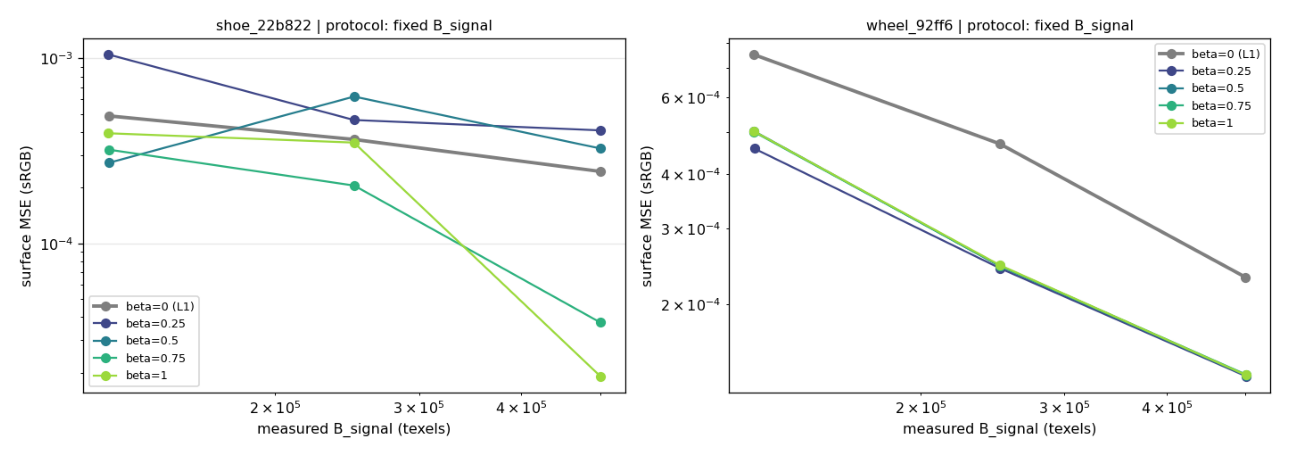

In [9]:
p1b = jload(f"{OUT}/p1b/summary.json")
if p1b:
    v = p1b["verdict"]
    base = {r["asset"]: r["per_beta"]["0.0"]["auc"] for r in p1b["assets"]}
    print("β × 资产 × global AUC (fixed-B_signal, log2 域; 括号=相对 β=0):")
    hdr = f"{'beta':>6s}" + "".join(f"{r['asset']:>28s}" for r in p1b["assets"])
    print(hdr); print("-" * len(hdr))
    for b in p1b["assets"][0]["betas"]:
        row = f"{b:>6g}"
        for r in p1b["assets"]:
            auc = r["per_beta"][str(b)]["auc"]
            row += f"{auc:>17.6f} ({auc/base[r['asset']]:>5.2f}x)"
        print(row)
    print()
    print(f"达标 β: {v['qualifying_betas']}   最佳共享 β = {v['best_shared_beta']}")
    print(f"结论: {v['status']}")
    for r in p1b["assets"]:
        b = str(v["best_shared_beta"])
        print(f"  {r['asset']:24s} 高频区 AUC: β=0 {r['per_beta']['0.0']['auc_hifreq']:.6f}"
              f" -> β={b} {r['per_beta'][b]['auc_hifreq']:.6f} | "
              f"fixed-B_raw 对照 AUC: {r['fixed_braw']['0.0']['auc']:.6f}"
              f" -> {r['fixed_braw'][b]['auc']:.6f}")
        print(f"  {'':24s} cache: charts={r['cache']['n_charts']} "
              f"face2chart_sha1={r['cache']['face2chart_sha1']} "
              f"eval_hash={r['eval_sample_hash']}")
    show_row([f"{OUT}/p1b/p1b_fixed_bsignal_curves.png"], figw=13)
else:
    print(f"无 P1b 数据: {OUT}/p1b/summary.json")

## 9. 当前准确结论 / 尚未验证事项 / 下一步

### 已确认
1. **P0 mechanism：PASS**——三资产 e_chart 大幅下降（鞋 0.437→0.055），
   分配机制正确实现，残差主要来自 within-chart 异质性。
2. **P1/P1a diagnostic run：完成**。fixed-B_raw 协议（β=0.4）下：
   **wheel 改善、shoe 退化——均为 provisional case-study observation**。
3. **P1b（Simple V1 收口）：case-study validated**——严格等 B_signal、共享
   **β=0.75** 下鞋 AUC ×0.53、车轮 ×0.59（β=1.0 亦达标）；高频区辅助指标同步改善
   （鞋 ×0.14、车轮 ×0.64）。shoe 此前在 β=0.4 的退化确证**以强度失配为主**
   （β=0.25/0.5 劣化、0.75 改善），信号排序在该 β 下未构成阻碍。
   **只声称在当前两资产案例上通过，不声称普遍有效。**
4. RD_hull 分配仅作诊断参考（teacher candidate v0），不参与 Simple V1 定义。

### 尚未验证
- 多资产 paired + bootstrap 统计（Simple V1 只在鞋+车轮两案例验证）。
- **raw R-D 校准**：凸包 envelope 与可实现离散 bake 方案之间的差距未量化。
- chart 粒度作为次级瓶颈的影响未量化。
- 鞋上 β 响应非单调（0.25/0.5 劣化、0.75/1.0 改善）的机理未深究——如实记录，不过度解释。

### 下一步
**Simple V1 已按预定停止条件冻结（case-study validated，共享 β=0.75），等待确认。**
不自动进入 gradient / chart split / 其他阶段；
以下继续冻结：multiscale、轻量预测器、chart split、multi-atlas、UniTEX、PBR。

### 索引
报告：`纹理密度/p0_validation_report.md`、`p1_quality_report.md`、`p1a_fairness_report.md`；
代码：`code/tdlib/`（8 模块，24/24 测试）、`code/scripts/run_p{0,1,1a}.py`、
`code/scripts/gen_dashboard_assets.py`（素材）、`code/scripts/build_dashboard_notebook.py`（本页）。

---

# 技术附录

## A1. 预算核算：B_raw / B_signal / B_pad / B_empty

固定 R 只固定 B_raw；chart 缩放改变 shelf 装箱形状，因此各方法 **B_signal 不同**。
这是"固定 R ≠ 固定有效纹素预算"的量化依据（P1a 第 1 项）。

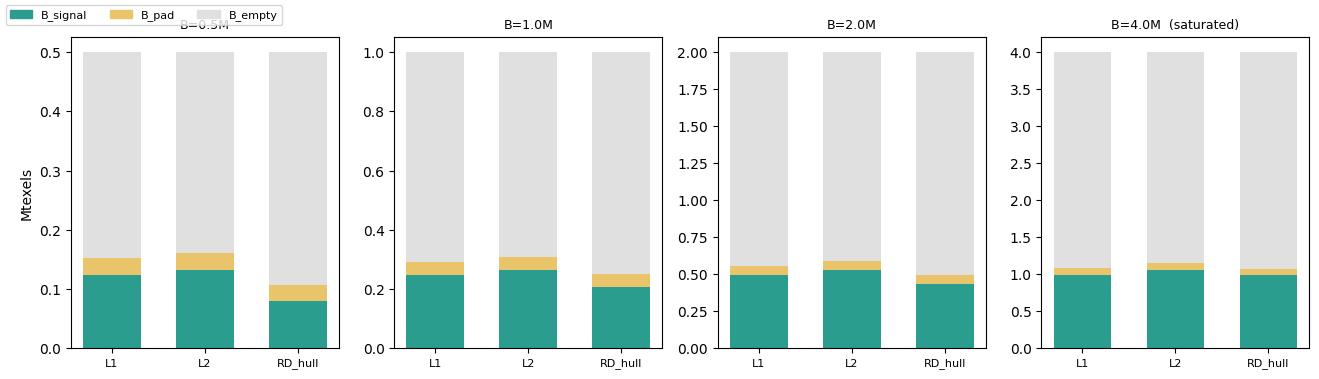

  budget  method                                            B_raw   B_signal     B_pad    B_empty
-------------------------------------------------------------------------------------------------
    0.5M  L1 uniform                                      499,849    124,408    27,796    347,645
    0.5M  L2 luminance-std                                499,849    132,575    28,110    339,164
    0.5M  RD_hull_global_mse — teacher candidate v0       499,849     80,609    26,192    393,048
    1.0M  L1 uniform                                    1,000,000    248,772    41,185    710,043
    1.0M  L2 luminance-std                              1,000,000    265,346    41,698    692,956
    1.0M  RD_hull_global_mse — teacher candidate v0     1,000,000    207,124    43,039    749,837
    2.0M  L1 uniform                                    1,999,396    497,223    59,615  1,442,558
    2.0M  L2 luminance-std                              1,999,396    530,384    59,835  1,409,177
    2.0M  RD_hull_gl

In [10]:
m = p1a.get(ASSET)
if not m:
    print(f"该资产无 P1a 数据: {OUT}/p1a/{ASSET}/metrics.json")
else:
    import matplotlib.patches as mpatches
    Bs = m["budgets"]; sat = set(m["saturated_budgets"])
    PARTS = [("B_signal", "#2a9d8f"), ("B_pad", "#e9c46a"), ("B_empty", "#e0e0e0")]
    fig, axs = plt.subplots(1, len(Bs), figsize=(3.3 * len(Bs), 3.8))
    for ax, B in zip(np.atleast_1d(axs), Bs):
        for i, meth in enumerate(METHODS):
            d = m["per_budget"][str(B)][P1A_KEY[meth]]
            bot = 0.0
            for part, cc in PARTS:
                ax.bar(i, d[part] / 1e6, bottom=bot, color=cc, width=0.62)
                bot += d[part] / 1e6
        t = f"B={B/1e6:.1f}M" + ("  (saturated)" if B in sat else "")
        ax.set_title(t, fontsize=9)
        ax.set_xticks(range(len(METHODS)))
        ax.set_xticklabels(["L1", "L2", "RD_hull"], fontsize=8)
    np.atleast_1d(axs)[0].set_ylabel("Mtexels")
    fig.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in PARTS],
               loc="upper left", fontsize=8, ncol=3)
    plt.tight_layout(); plt.show()

    hdr = f"{'budget':>8s}  {'method':44s} {'B_raw':>10s} {'B_signal':>10s} {'B_pad':>9s} {'B_empty':>10s}"
    print(hdr); print("-" * len(hdr))
    for B in Bs:
        for meth in METHODS:
            d = m["per_budget"][str(B)][P1A_KEY[meth]]
            print(f"{B/1e6:>7.1f}M  {LABEL[meth]:44s} {d['B_raw']:>10,} "
                  f"{d['B_signal']:>10,} {d['B_pad']:>9,} {d['B_empty']:>10,}")
    print()
    print("→ 受控的 fixed-B_signal 协议 NOT YET EVALUATED; 上述差异当前仅透明报告。")

## A2. Chart R-D 曲线：原始采样点 vs monotone + 下凸包

展示凸包修正幅度最大的 3 个 chart。灰 × = 原始 5 档采样（存在非单调/非凸，违反贪心的
边际收益递减前提），红 ○─ = 分配所用的处理后曲线。

**注意：红线为诊断 envelope，线段上的中间点不一定是可实现的离散 bake 方案**
（可实现方案只有离散档位点；raw R-D 校准属 P1b 范围）。

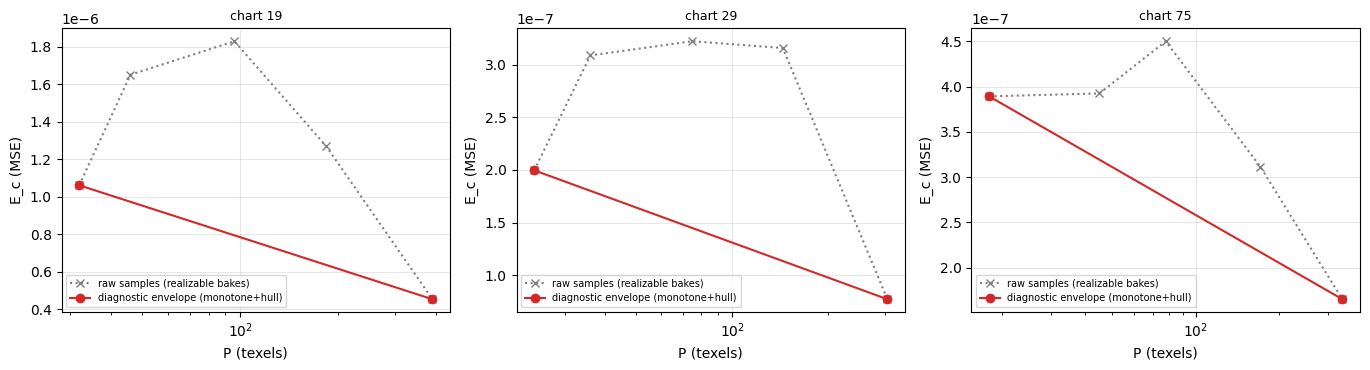

凸包诊断 (shoe_22b822): 非单调 51, 非凸 65 / 150 有效 charts
注: 红线为诊断 envelope, 线段上的中间点不一定是可实现的离散 bake 方案。


In [11]:
pts = rdpt.get(ASSET)
if not pts:
    print(f"该资产无 R-D 素材: {OUT}/dashboard/{ASSET}/rd_points.json")
else:
    fig, axs = plt.subplots(1, len(pts), figsize=(4.6 * len(pts), 3.8))
    for ax, e in zip(np.atleast_1d(axs), pts):
        ax.plot(e["raw"]["P"], e["raw"]["E"], "x:", color="tab:gray",
                label="raw samples (realizable bakes)")
        ax.plot(e["hull"]["P"], e["hull"]["E"], "o-", color="tab:red",
                label="diagnostic envelope (monotone+hull)")
        ax.set_xscale("log"); ax.set_xlabel("P (texels)"); ax.set_ylabel("E_c (MSE)")
        ax.set_title(f"chart {e['chart']}", fontsize=9)
        ax.grid(alpha=0.3); ax.legend(fontsize=7)
    plt.tight_layout(); plt.show()
    d = dash.get(ASSET)
    if d:
        hd = d["hull_diag"]
        print(f"凸包诊断 ({ASSET}): 非单调 {hd['n_nonmonotone']}, "
              f"非凸 {hd['n_nonconvex']} / {hd['n_eval']} 有效 charts")
    print("注: 红线为诊断 envelope, 线段上的中间点不一定是可实现的离散 bake 方案。")

## A3. Rebake atlas 全图（1000²）

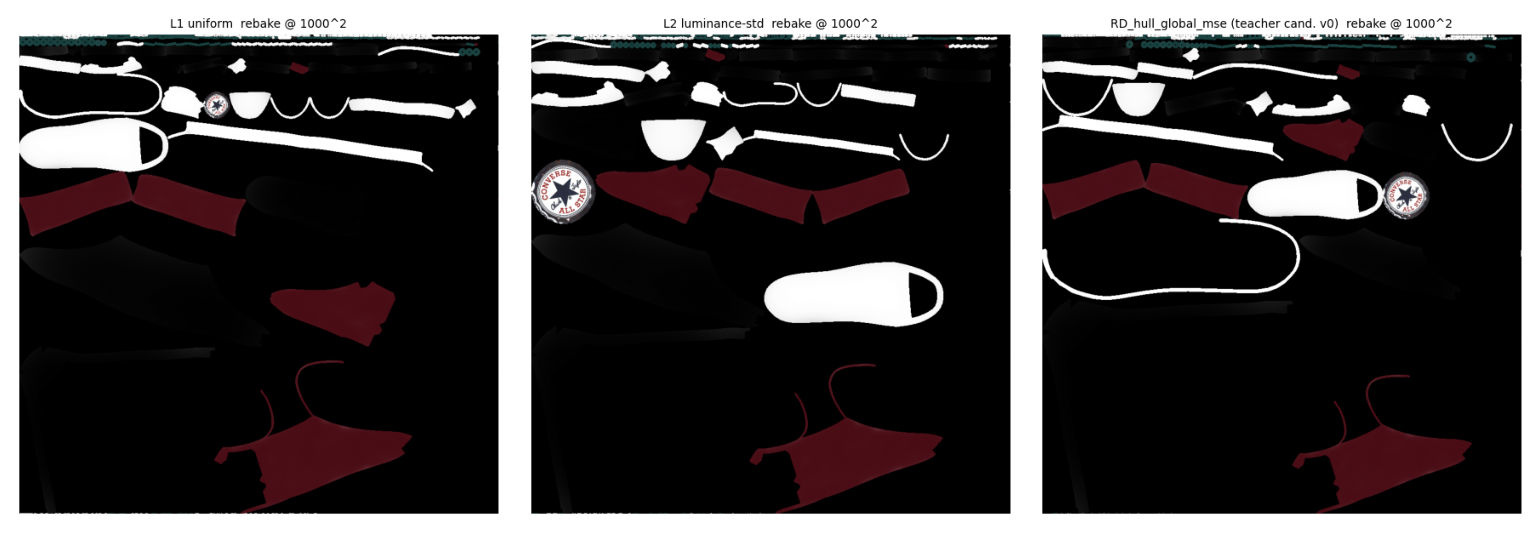

In [12]:
show_row([f"{OUT}/dashboard/{ASSET}/rebake_{m}.png" for m in METHODS])

## A4. 协议与可复现性

- 评价协议：150k 面积加权表面采样、sRGB surface MSE、bilinear 重建 + 2 轮 gutter dilation；
  R-D 曲线采样（seed=1）与质量评价采样（seed=2）严格分离。
- 饱和规则：L1 的 B_signal ≥ reference 被引用纹素数 ⇒ 该预算点剔出主 AUC。
- 素材再生成（`geomae` 环境、`code/` 目录下）：
  `python scripts/run_p0.py` → `run_p1.py` → `run_p1a.py` → `gen_dashboard_assets.py`
  → `build_dashboard_notebook.py` → `jupyter nbconvert --to notebook --execute --inplace
  notebook/partuv_td_test.ipynb`。
- 资产切换（`ASSET` 参数）仅在原项目目录有效；共享副本请连同 `outputs/` 一起拷贝。
- **跨运行非确定性**：PartUV（PartField 推理/聚类）的 chart 分解存在轻微的
  run-to-run 漂移（实测 interior texel 计数 ~0.5%、zoom chart 可能落到相邻同类
  chart）。本 dashboard 素材内部自洽（同一次运行生成）；与 `outputs/p1a` 指标
  来自不同运行，数值允许有微小差异。

In [13]:
for a in ["shoe_22b822", "wheel_92ff6"]:
    m = p1a.get(a)
    if m:
        print(f"{a:24s} sample hashes: {m['sample_hashes']}   "
              f"ref_used_texels={m['ref_used_texels']:,}")

shoe_22b822              sample hashes: {'curve': 'ea8c56f9f6f7e1f5', 'eval': 'c720923498a79eae'}   ref_used_texels=660,806
wheel_92ff6              sample hashes: {'curve': '37c276c58c13ec33', 'eval': '995534c5898aeb73'}   ref_used_texels=1,394,647
